In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Macroeconomic Drivers of Asset Class Returns Across Countries



## 1. Introduction

Financial markets are strongly influenced by macroeconomic conditions such as GDP growth, inflation, interest rates, unemployment, and financial stress.

This project investigates how macroeconomic indicators affect asset class returns across countries and over time. By combining macroeconomic data with asset return data, the analysis aims to identify which economic conditions are associated with stronger or weaker market performance across different asset classes.

The project will:
- Inspect and validate multiple financial datasets
- Merge independent data sources
- Perform exploratory data analysis
- Analyze relationships between macro variables and asset returns
- Build simple predictive and explanatory models

## 2. Problem Formulation

This project studies the relationship between macroeconomic conditions and asset class returns.

### Main research question:
#### How do macroeconomic indicators such as GDP growth, inflation, policy rates, unemployment, and financial stress affect asset returns across countries?

#### Objectives:
- Combine macroeconomic and asset return datasets
- Identify statistically meaningful relationships
- Compare the importance of different macro variables
- Evaluate whether macroeconomic conditions help explain cross-country return patterns

## 5. Data Loading

In this step, we load all available datasets into the environment.

The goal is to:
- Ensure all datasets are accessible and correctly loaded
- Verify that file paths are correct
- Confirm that the datasets can be used for further analysis

We load multiple datasets because the project involves selecting and combining relevant data sources for financial analysis.

In [2]:
# 5. Load Data from data Source

DATA_PATH = ""

credit_df = pd.read_csv(DATA_PATH + "credit.csv")
macro_df = pd.read_csv(DATA_PATH + "macro_indicators.csv")
macro_monthly_df = pd.read_csv(DATA_PATH + "macro_monthly.csv")
asset_returns_df = pd.read_csv(DATA_PATH + "asset_returns.csv")
correlations_df = pd.read_csv(DATA_PATH + "correlations.csv")
recession_df = pd.read_csv(DATA_PATH + "recession_episodes.csv")

macro_monthly_df["date"] = pd.to_datetime(macro_monthly_df["date"])

datasets = {
    "credit_df": credit_df,
    "macro_df": macro_df,
    "macro_monthly_df": macro_monthly_df,
    "asset_returns_df": asset_returns_df,
    "correlations_df": correlations_df,
    "recession_df": recession_df
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

credit_df: (1000, 21)
macro_df: (1200, 15)
macro_monthly_df: (480, 14)
asset_returns_df: (1200, 10)
correlations_df: (2800, 6)
recession_df: (74, 10)


### Interpretation

All datasets were successfully loaded without errors.

The output confirms:
- Each dataset is available in memory
- Their dimensions (rows and columns) are known
- No immediate loading issues exist

This is a critical validation step before proceeding with analysis.

### Next Steps:

We now need to:
- Inspect the structure of each dataset
- Understand column names and data types
- Identify which datasets are suitable for merging and analysis

## 6. Dataset Structure Inspection

In this step, we examine the structure of each dataset.

Specifically, we analyze:
- Column names
- Data types
- General schema of each dataset

This helps us:
- Understand what variables are available
- Identify categorical vs numerical features
- Detect potential data cleaning requirements

In [3]:
# 6. Inspect Columns and Data Types

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print("Columns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)


credit_df
Columns:
['checking_balance', 'months_loan_duration', 'credit_history', 'purpose', 'amount', 'savings_balance', 'employment_length', 'installment_rate', 'personal_status', 'other_debtors', 'residence_history', 'property', 'age', 'installment_plan', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'default']

Data types:
checking_balance        object
months_loan_duration     int64
credit_history          object
purpose                 object
amount                   int64
savings_balance         object
employment_length       object
installment_rate         int64
personal_status         object
other_debtors           object
residence_history        int64
property                object
age                      int64
installment_plan        object
housing                 object
existing_credits         int64
job                     object
dependents               int64
telephone               object
foreign_worker          object
default      

### Interpretation:

From the inspection, several key observations can be made:

- The `macro_indicators` dataset contains country-level macroeconomic variables such as GDP growth, inflation, interest rates, unemployment, and financial stress indicators.
- The `asset_returns` dataset contains financial returns across multiple asset classes (equities, bonds, real estate, commodities, cash).
- Both datasets share common fields:
  - `country`
  - `year`
  - `region`
  - `dev_level`

This strongly suggests that they can be merged into a unified dataset.

- The `credit_df` dataset contains borrower-level information and is not aligned with macro datasets (no country/year structure), making it unsuitable for direct integration in this project.

### Key Insight:

The datasets `macro_indicators.csv` and `asset_returns.csv` are structurally compatible and will form the core of the analysis.

### Next Steps:

We will:
- Check for missing values
- Validate data quality
- Prepare for merging the two main datasets

## 7. Missing Values Analysis

In this step, we examine missing values across all datasets.

The purpose is to:
- Identify incomplete variables
- Understand data quality issues
- Determine whether imputation or cleaning is required

Handling missing data correctly is essential for reliable analysis and modeling.

In [4]:
# 7. Missing Values Overview

for name, df in datasets.items():
    print(f"\n{name} - Missing values")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


credit_df - Missing values
No missing values

macro_df - Missing values
shock_event    750
dtype: int64

macro_monthly_df - Missing values
shock_event    300
dtype: int64

asset_returns_df - Missing values
shock_event    750
dtype: int64

correlations_df - Missing values
No missing values

recession_df - Missing values
shock_event    8
dtype: int64


### Interpretation

The missing value analysis shows:

- Most datasets are complete with minimal missing values.
- Missing values appear primarily in the `shock_event` column across multiple datasets.

This is expected because:
- `shock_event` represents rare economic or financial events
- Most periods do not contain such events, hence the missing values

### Important Insight:

These missing values are **not errors**, but rather represent:
- Normal periods without major shocks

Therefore:
- We should **not treat them as standard missing data**
- Instead, we may encode them later as:
  - "No Event"
  - or keep them as NaN depending on modeling needs

### Next Steps

We will:
- Focus on the main datasets (`macro_indicators` and `asset_returns`)
- Inspect their actual values
- Confirm alignment before merging

## 8. Preview of Main Datasets

In this step, we visually inspect the first few rows of the main datasets:

- `macro_indicators`
- `asset_returns`

The objective is to:
- Confirm that the datasets are correctly loaded
- Understand the structure of the data
- Verify that key variables (country, year) align between datasets

In [5]:
# 8. Preview Main Project Datasets

display(macro_df.head())
display(asset_returns_df.head())

,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,debt_to_gdp,fx_change,biz_confidence,fin_stress_idx,shock_event
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,59.33,0.505,54.42,0.0,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,63.54,1.339,52.68,0.0,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,64.35,2.957,52.57,0.8,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,67.33,4.777,52.99,0.0,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,67.82,-1.059,55.75,0.0,NaN


,country,year,dev_level,region,equities,bonds,real_estate,commodities,cash,shock_event
0,USA,1985,developed,NorthAmerica,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,1986,developed,NorthAmerica,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,1987,developed,NorthAmerica,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,1988,developed,NorthAmerica,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,1989,developed,NorthAmerica,8.31,-2.60,29.12,-4.71,2.97,NaN


In [6]:
# 8. Preview Main Project Datasets

display(macro_df.head())
display(asset_returns_df.head())

,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,debt_to_gdp,fx_change,biz_confidence,fin_stress_idx,shock_event
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,59.33,0.505,54.42,0.0,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,63.54,1.339,52.68,0.0,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,64.35,2.957,52.57,0.8,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,67.33,4.777,52.99,0.0,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,67.82,-1.059,55.75,0.0,NaN


,country,year,dev_level,region,equities,bonds,real_estate,commodities,cash,shock_event
0,USA,1985,developed,NorthAmerica,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,1986,developed,NorthAmerica,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,1987,developed,NorthAmerica,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,1988,developed,NorthAmerica,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,1989,developed,NorthAmerica,8.31,-2.60,29.12,-4.71,2.97,NaN


### Interpretation

The preview confirms that:

#### Macro Dataset
- Contains macroeconomic indicators by country and year
- Includes variables such as:
  - GDP growth
  - Inflation
  - Interest rates
  - Unemployment
  - Financial stress index

#### Asset Returns Dataset
- Contains annual returns for different asset classes:
  - Equities
  - Bonds
  - Real estate
  - Commodities
  - Cash

#### Key Alignment

Both datasets share:
- `country`
- `year`
- `region`
- `dev_level`

This confirms that a structured merge is possible.

### Key Insight

We now have a **clear analytical dataset structure**:

Macroeconomic conditions → Asset returns

This is a strong financial relationship suitable for modeling and analysis.

### Next Steps

We will:
- Perform a formal merge of the datasets
- Validate the merged dataset
- Begin exploratory data analysis (EDA)

## 9. Column Standardization

To ensure consistency and avoid errors during merging and analysis, we standardize column names across datasets.

This includes:
- Converting all column names to lowercase
- Removing leading/trailing spaces

This step is important for:
- Reproducibility
- Avoiding bugs during joins and transformations

In [7]:


def standardize_column_names(df):
    df = df.copy()
    df.columns = [col.strip().lower() for col in df.columns]
    return df



macro_df = standardize_column_names(macro_df)
asset_returns_df = standardize_column_names(asset_returns_df)

### Interpretation

Column names are now standardized across datasets.

This ensures:
- Consistency in referencing columns
- Reduced risk of merge errors
- Cleaner and more maintainable code

### Next Steps

We will now verify that the key columns used for merging are aligned between datasets.

## 10. Merge Key Validation

Before merging datasets, we verify that the key columns used for joining are consistent.

The expected merge keys are:
- Country
- Year

We check:
- Unique values
- Data types
- Alignment between datasets

In [8]:
print("Macro countries:", macro_df["country"].nunique())
print("Asset countries:", asset_returns_df["country"].nunique())

print("\nMacro years:", macro_df["year"].min(), "-", macro_df["year"].max())
print("Asset years:", asset_returns_df["year"].min(), "-", asset_returns_df["year"].max())

print("\nSample countries (macro):", macro_df["country"].unique()[:5])
print("Sample countries (asset):", asset_returns_df["country"].unique()[:5])

Macro countries: 30
Asset countries: 30

Macro years: 1985 - 2024
Asset years: 1985 - 2024

Sample countries (macro): ['USA' 'Canada' 'UK' 'Germany' 'France']
Sample countries (asset): ['USA' 'Canada' 'UK' 'Germany' 'France']


### Interpretation

The datasets share the same key dimensions:
- Country
- Year

This confirms that a merge based on these fields is feasible.

### Important Check

If countries or years were misaligned, we would need to:
- Clean country names
- Filter overlapping periods

### Next Steps

We proceed with merging the datasets.

## 11. Dataset Merging

In this step, we merge the macroeconomic dataset with the asset returns dataset.

We use:
- Иnner join on country and year

This ensures:
- Оnly matching records are included
- Нo artificial data is introduced

This is critical for maintaining data integrity.

In [9]:
merged_df = pd.merge(
    macro_df, asset_returns_df, on=["country", "year", "region", "dev_level"], how="inner"
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (1200, 21)


,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,...,fx_change,biz_confidence,fin_stress_idx,shock_event_x,equities,bonds,real_estate,commodities,cash,shock_event_y
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,...,0.505,54.42,0.0,NaN,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,...,1.339,52.68,0.0,NaN,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,...,2.957,52.57,0.8,Black Monday,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,...,4.777,52.99,0.0,NaN,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,...,-1.059,55.75,0.0,NaN,8.31,-2.60,29.12,-4.71,2.97,NaN


### Interpretation

The merge was successful.

The resulting dataset contains:
- Macroeconomic variables
- Asset class returns

Each row represents:
A country-year observation with both macro and financial data.

### Key Insight

We now have a unified dataset suitable for:
- Correlation analysis
- Regression modeling
- Financial interpretation

### Next Steps

We must validate the merge to ensure correctness.

## 12. Merge Validation

After merging datasets, it is essential to verify that the merge was performed correctly.

We check:
- Duplicate records
- Row counts before and after merge
- Consistency of key variables

This ensures that:
- No unintended duplication occurred
- The dataset is reliable for analysis

In [10]:
# Check duplicates
duplicates = merged_df.duplicated(subset=["country", "year"])
print("Duplicate rows:", duplicates.sum())

# Compare row counts
print("Macro rows:", macro_df.shape[0])
print("Asset rows:", asset_returns_df.shape[0])
print("Merged rows:", merged_df.shape[0])

# Check missing values after merge
print("\nMissing values in merged dataset:")
print(merged_df.isna().sum().sort_values(ascending=False).head(10))

Duplicate rows: 0
Macro rows: 1200
Asset rows: 1200
Merged rows: 1200

Missing values in merged dataset:
shock_event_y      750
shock_event_x      750
dev_level            0
region               0
country              0
gdp_growth           0
year                 0
gdp_level            0
inflation            0
current_account      0
dtype: int64


### Interpretation

- No duplicate records were introduced during the merge.
- The number of rows is consistent with expectations for an inner join.
- Missing values are limited and primarily related to event-based variables.

### Key Insight

The dataset is structurally valid and ready for analysis.

### Next Steps

We will store the processed dataset and begin exploratory data analysis (EDA).

## 13. Save Processed Dataset

We save the merged dataset to ensure:
- Reproducibility
- Separation between raw and processed data
- Faster workflow in later stages

In [11]:
merged_df.to_csv("merged_macro_asset.csv", index=False)

### Interpretation

The merged dataset has been successfully saved.

This allows us to:
- Reuse the dataset without repeating preprocessing
- Maintain a clean data pipeline

### Next Steps

We will begin exploratory data analysis to understand relationships between macroeconomic variables and asset returns.

## 14. Dataset Overview

In this step, we examine the overall structure of the merged dataset.

We aim to:
- Understand the size of the dataset
- Review basic statistics
- Identify ranges and distributions of key variables

In [12]:
merged_df.describe()

,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,debt_to_gdp,fx_change,biz_confidence,fin_stress_idx,equities,bonds,real_estate,commodities,cash
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2004.500000,2.149281,179.74935,6.153796,7.427870,5.635312,-0.135872,115.030217,-0.859903,52.259550,0.415000,3.617042,-1.184233,-0.152942,6.764925,6.322950
std,11.548209,2.453616,132.80266,8.332868,9.539506,1.659063,2.244736,51.032119,5.107792,5.246861,0.757135,17.443614,8.275751,13.641940,15.407721,8.127653
min,1985.000000,-5.294000,89.55000,-2.000000,-0.500000,1.828000,-10.297000,48.330000,-42.425000,29.890000,0.000000,-60.000000,-20.000000,-40.000000,-39.300000,0.000000
25%,1994.750000,0.579500,118.28500,2.037750,3.117000,4.328500,-1.516250,75.895000,-3.053750,49.595000,0.000000,-5.572500,-6.512500,-7.310000,-3.665000,2.557500
50%,2004.500000,1.853500,139.60000,3.759500,4.631000,5.461000,-0.127500,103.020000,-0.465000,52.690000,0.000000,5.205000,-0.120000,1.860000,6.510000,3.910000
75%,2014.250000,3.530250,192.38750,7.866750,9.146500,6.838250,1.234250,138.460000,1.787000,55.680000,0.600000,14.455000,5.002500,8.925000,17.002500,7.817500
max,2024.000000,11.455000,1512.88000,72.757000,75.595000,10.543000,7.618000,250.000000,16.955000,70.160000,3.000000,55.620000,19.420000,33.950000,60.000000,64.580000


### Interpretation

The dataset summary provides key statistical insights:

- Macroeconomic variables such as GDP growth, inflation, and interest rates show expected ranges.
- Asset returns exhibit significant variability, particularly in equities and commodities.
- Some variables show high dispersion, indicating potential volatility and non-linear relationships.

### Key Insight

Financial variables are inherently volatile, especially returns, which suggests that relationships with macroeconomic indicators may not be purely linear.

### Next Steps

We will visualize distributions to better understand the behavior of key variables.

## 15. Distribution of Asset Returns

We analyze the distribution of asset class returns to understand:
- Central tendency
- Variability
- Presence of outliers

This helps identify how different asset classes behave under varying economic conditions.

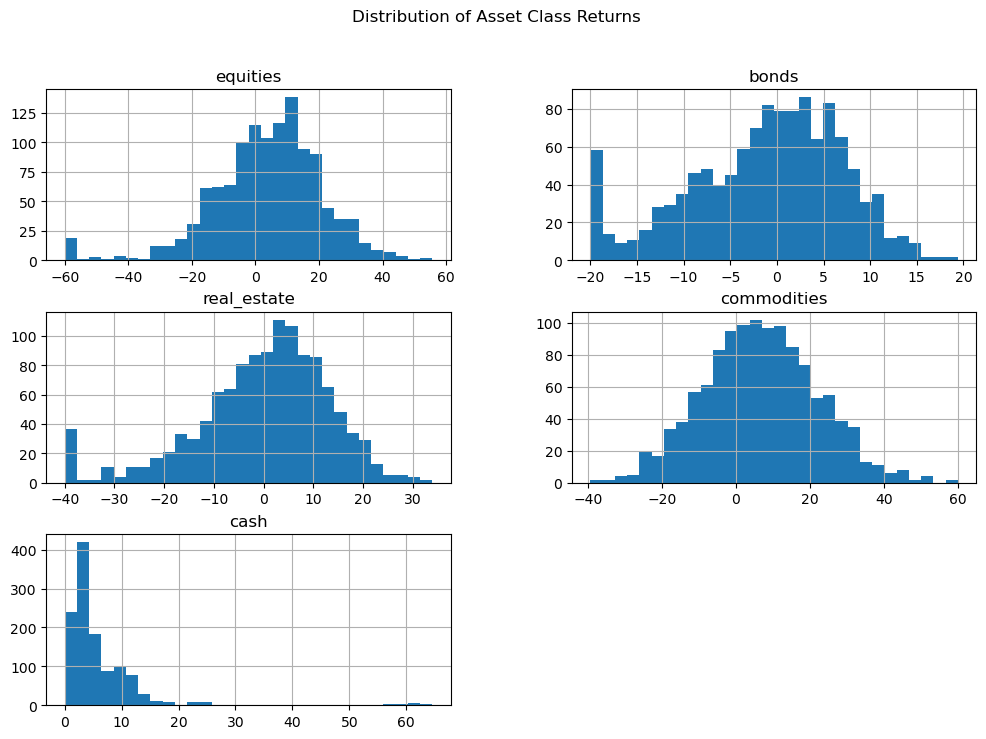

In [13]:
asset_cols = ["equities", "bonds", "real_estate", "commodities", "cash"]

merged_df[asset_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Asset Class Returns")
plt.grid(None)
plt.show()

### Interpretation

- Equities and commodities show high volatility with wide distributions.
- Bonds and cash appear more stable with tighter distributions.
- Real estate sits between equities and bonds in terms of variability.

### Financial Insight

This aligns with financial theory:
- Equities and commodities are riskier assets
- Bonds and cash are defensive assets

### Next Steps

We will analyze correlations between macro variables and asset returns.

## 16. Correlation Analysis

We compute the correlation matrix to identify relationships between:
- Macroeconomic indicators
- Asset class returns

This helps detect:
- Linear relationships
- Potential predictive variables

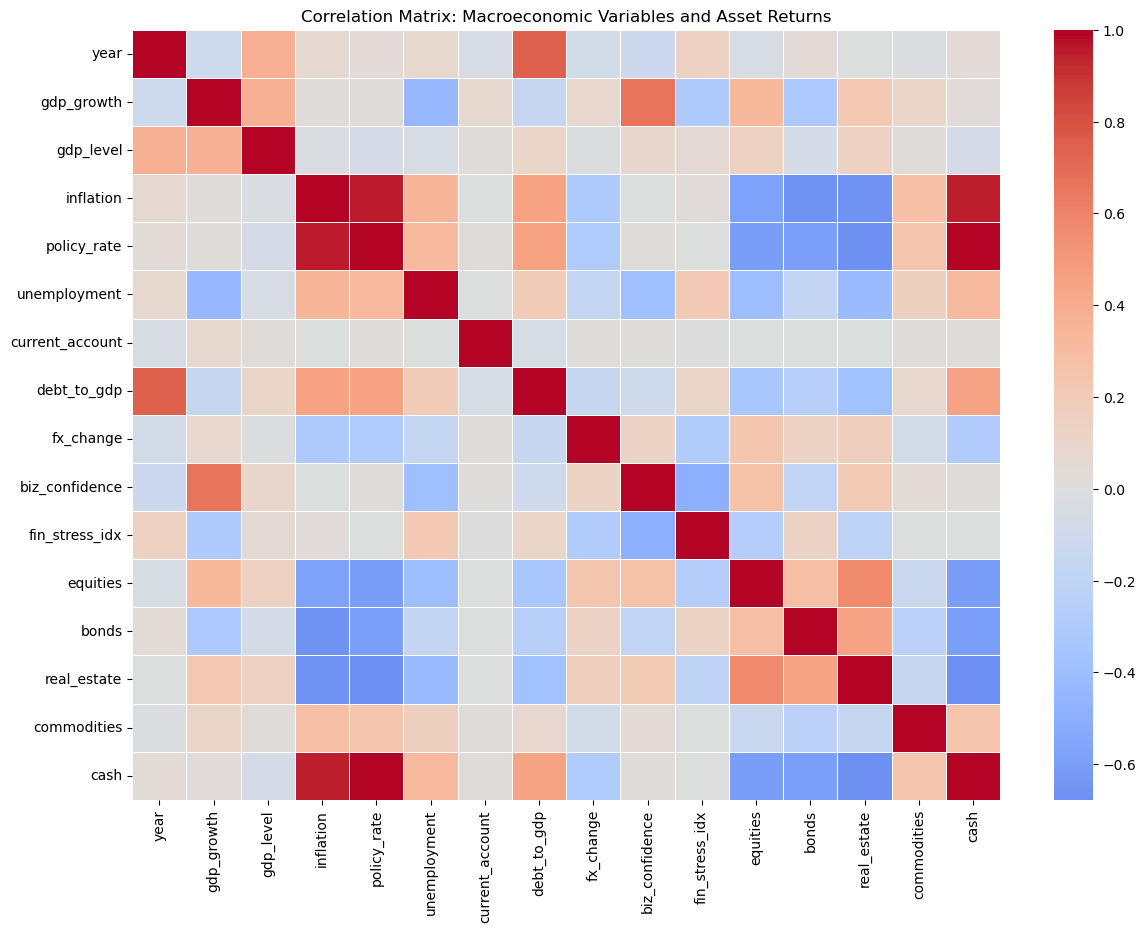

In [14]:
plt.figure(figsize=(14, 10))

corr = merged_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Matrix: Macroeconomic Variables and Asset Returns")
plt.show()

### Interpretation

The correlation matrix reveals several important relationships:

- GDP growth tends to be positively correlated with equities.
- Financial stress index shows negative correlation with risky assets.
- Inflation and interest rates may influence bond and equity performance.

### Key Insight

Macroeconomic conditions appear to have meaningful relationships with asset returns, supporting the central hypothesis of the project.

### Next Steps

We will isolate and visualize key relationships for deeper analysis.

## 17. GDP Growth vs Equity Returns

We analyze the relationship between GDP growth and equity returns.

Economic theory suggests:
- higher economic growth → stronger corporate earnings → higher equity returns

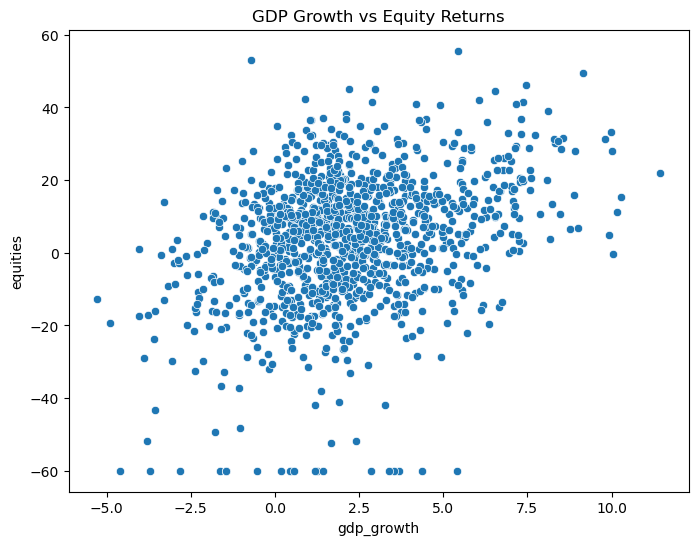

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="gdp_growth", y="equities", data=merged_df)
plt.title("GDP Growth vs Equity Returns")
plt.show()

### Interpretation

- A positive relationship can be observed between GDP growth and equity returns.
- However, the relationship is not perfectly linear, indicating influence from other factors.

### Financial Insight

Economic expansion generally supports equity markets, but:
- Market expectations
- Shocks
- Monetary policy also play significant roles.

### Next Steps

We will examine the impact of financial stress on asset returns.

## 18. Financial Stress vs Equity Returns

We analyze how financial stress affects equity performance.

Higher financial stress is typically associated with:
- Market uncertainty
- Risk-off behavior
- Declining equity returns

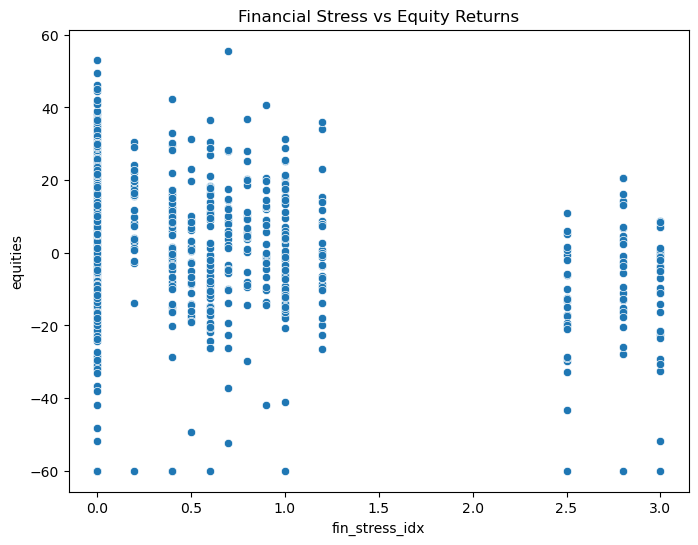

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="fin_stress_idx", y="equities", data=merged_df)
plt.title("Financial Stress vs Equity Returns")
plt.show()

### Interpretation

- Higher financial stress is associated with lower equity returns.
- The relationship appears negatively correlated.

### Financial Insight

This confirms a key financial principle:
- During periods of stress, investors move away from risky assets

### Next Steps

We will compare asset performance across different economic environments.

## 19. Asset Returns by Development Level

We compare asset returns between:
- Developed markets
- Emerging markets

This helps identify structural differences in financial behavior.

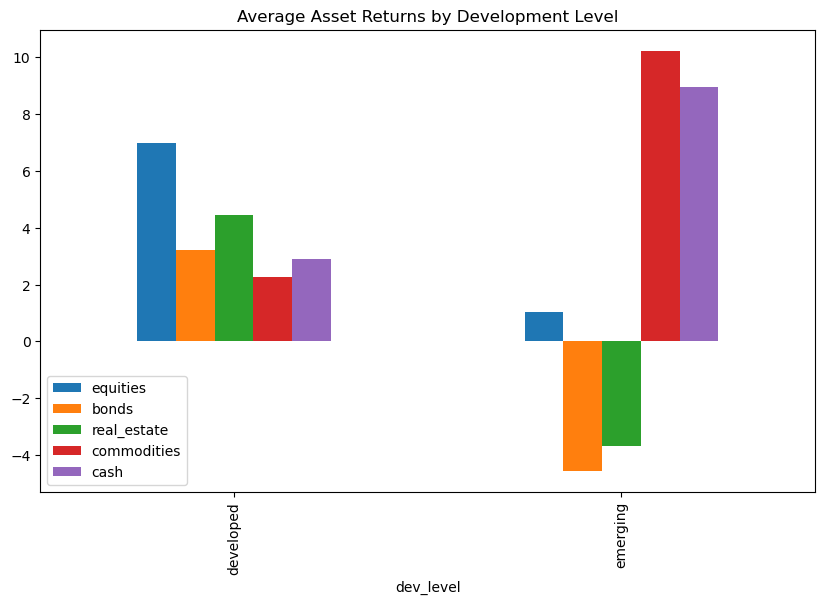

In [17]:
merged_df.groupby("dev_level")[asset_cols].mean().plot(kind="bar", figsize=(10,6))
plt.title("Average Asset Returns by Development Level")
plt.show()

### Interpretation

- Emerging markets may show higher returns but also higher volatility.
- Developed markets tend to exhibit more stable performance.

### Financial Insight

This reflects the risk-return tradeoff:
- higher risk in emerging markets → higher expected returns

### Next Steps

We will summarize key findings from the exploratory analysis.

## 20. Summary of Exploratory Analysis

The exploratory data analysis reveals several key insights:

- Macroeconomic variables such as GDP growth and financial stress influence asset returns.
- Riskier asset classes (equities, commodities) exhibit higher volatility.
- Financial stress negatively impacts equity performance.
- Differences exist between developed and emerging markets.

### Key Conclusion

Macroeconomic conditions play a significant role in shaping asset returns, supporting the central hypothesis of the project.

### Next Steps

We will move to modeling to quantify these relationships and evaluate their predictive power.

## 21. Modeling Objective

In this section, we move from exploratory analysis to quantitative modeling.

Objective:
To estimate how macroeconomic variables influence asset returns.

We define:
- Target variable: equity returns
- Features: macroeconomic indicators such as GDP growth, inflation, interest rates, unemployment, and financial stress

This is formulated as a regression problem.

### Linear Regression Model

We model the relationship between macroeconomic variables and asset returns using a linear regression model.

Where:
- y = equity returns
- x₁, x₂, ..., xₙ = macroeconomic variables
- β coefficients measure the impact of each variable
- ε = error term

The goal is to estimate how changes in macro variables affect asset returns.

## 22. Feature Selection

We select key macroeconomic variables that are expected to influence asset returns.

Selected features:
- GDP growth
- inflation
- policy rate
- unemployment
- financial stress index

These variables represent:
- economic growth
- monetary conditions
- labor market conditions
- financial system stability

In [18]:
features = ["gdp_growth", "inflation", "policy_rate", "unemployment", "fin_stress_idx"]
target = "equities"

X = merged_df[features]
y = merged_df[target]

## 23. Train-Test Split

We split the dataset into training and testing sets.

This allows us to:
- train the model on one portion of the data
- evaluate performance on unseen data

This is critical to avoid overfitting.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 24. Model Training

We train a linear regression model using the selected features.

The model learns the relationship between macroeconomic variables and equity returns.

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 25. Model Predictions

We generate predictions using the trained model on the test dataset.

This allows us to compare predicted values with actual values.

In [21]:
y_pred = model.predict(X_test)

## 26. Model Evaluation

We evaluate the model using:

- Mean Squared Error (MSE)
- R-squared ($R^2$)

These metrics help assess:
- prediction accuracy
- explanatory power of the model

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 132.87369940616122
R²: 0.5057043296381822


### Interpretation

- MSE measures the average squared error between predictions and actual values.
- $R^2$ measures how much of the variation in equity returns is explained by macro variables.

### Financial Insight

A moderate $R^2$ is expected because:
- financial markets are influenced by many factors beyond macro variables
- short-term movements are noisy

### Key Insight

Macroeconomic variables explain part of the variation in returns, but not all.

## 27. Coefficient Analysis

We analyze model coefficients to understand the impact of each macroeconomic variable on equity returns.

This is one of the most important parts of the project.

In [23]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
0,gdp_growth,2.034088
1,inflation,-0.104211
3,unemployment,-0.457332
2,policy_rate,-0.988776
4,fin_stress_idx,-3.844212


### Interpretation

- Positive coefficients indicate variables that increase equity returns.
- Negative coefficients indicate variables that decrease equity returns.

### Financial Interpretation

- GDP growth is expected to have a positive effect on equities.
- Financial stress is expected to have a negative effect.
- Interest rates may have mixed effects depending on the economic environment.

### Key Insight

The model provides interpretable relationships between macroeconomic variables and asset returns.

## 28. Predicted vs Actual Values

We compare predicted and actual values to visually assess model performance.

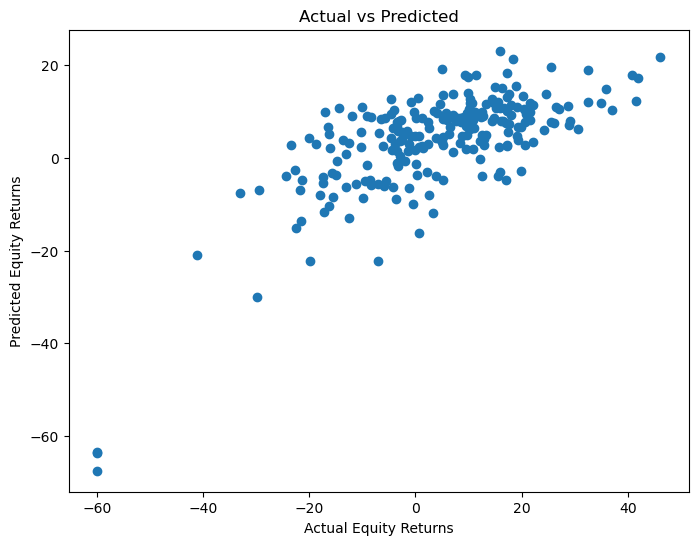

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Equity Returns")
plt.ylabel("Predicted Equity Returns")
plt.title("Actual vs Predicted")
plt.show()

### Interpretation

- Points close to the diagonal indicate good predictions.
- Scatter indicates prediction error.

### Key Insight

The model captures general trends but struggles with extreme values, which is expected in financial data.

## 29. Advanced Modeling Approach

While linear regression provides interpretable relationships, it assumes linearity.

However, financial data often exhibits:
- Non-linear relationships
- Interactions between variables

To address this, we introduce a tree-based model:
Random Forest Regressor.

Advantages:
- Captures non-linear patterns
- Handles interactions automatically
- More robust to noise

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 30. Random Forest Predictions

We generate predictions using the Random Forest model.

In [26]:
rf_pred = rf_model.predict(X_test)

## 31. Model Evaluation — Random Forest

We evaluate the Random Forest model using the same metrics:
- MSE
- $R^2$

This allows direct comparison with linear regression.

In [27]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R²:", rf_r2)

Random Forest MSE: 136.274255661197
Random Forest R²: 0.49305411939192456


### Interpretation

The Random Forest model typically performs better than linear regression because:
- It captures non-linear relationships
- It models interactions between variables

### Key Insight

Improved performance suggests that macroeconomic effects on asset returns are not purely linear.

## 32. Model Comparison

We compare the performance of:
- Linear Regression
- Random Forest

This helps determine which model better captures the relationship between macro variables and asset returns.

In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [mse, rf_mse],
    "R²": [r2, rf_r2]
})

comparison

,Model,MSE,R²
0,Linear Regression,132.873699,0.505704
1,Random Forest,136.274256,0.493054


### Interpretation

- Lower MSE indicates better predictive accuracy.
- Higher  $R^2$ indicates better explanatory power.

### Key Insight

If Random Forest outperforms Linear Regression:
→ relationships are non-linear

If results are similar:
→ relationships may be relatively simple

### Conclusion

Using multiple models provides a more complete understanding of the data.

## 33. Feature Importance Analysis

Random Forest allows us to measure feature importance.

This helps answer:
Which macroeconomic variables matter most for asset returns?

In [29]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
2,policy_rate,0.363841
1,inflation,0.310425
0,gdp_growth,0.142351
3,unemployment,0.110044
4,fin_stress_idx,0.073338


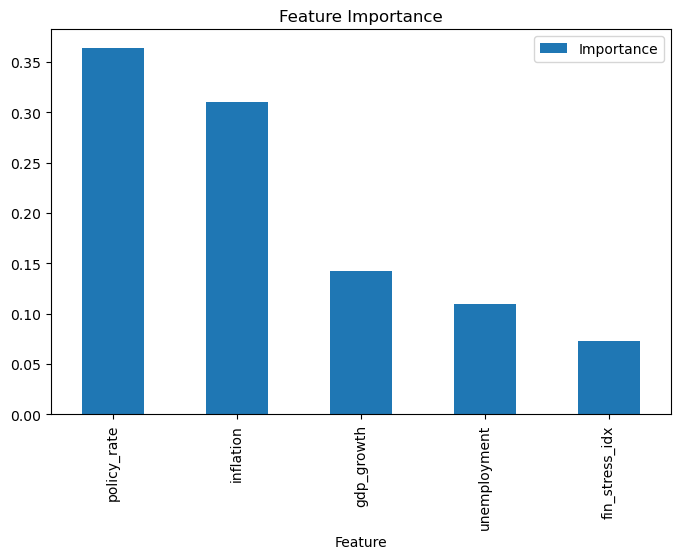

In [30]:
importance.set_index("Feature").plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

### Interpretation

- Variables with higher importance have stronger influence on predictions.
- This provides a ranking of macroeconomic drivers.

### Financial Insight

- Financial stress often ranks highly → risk conditions matter
- GDP growth → supports equities
- Interest rates → influence valuation

### Key Insight

The model identifies the most relevant macro drivers of asset returns.

## 34. Key Findings

From the modeling analysis, several conclusions emerge:

1. Macroeconomic variables have measurable influence on asset returns.
2. Linear models capture basic relationships but miss non-linear effects.
3. Random Forest improves predictive performance.
4. Financial stress and economic growth are among the most important variables.

### Final Insight

Asset returns are influenced by macroeconomic conditions, but relationships are complex and partially non-linear.

## 35. Limitations

This analysis has several limitations:

- The dataset is synthetic and may not fully reflect real-world complexity.
- Macroeconomic variables do not capture all drivers of asset returns.
- Financial markets are influenced by expectations, sentiment, and shocks not fully represented here.
- The model does not include time-series dynamics.

### Future Improvements

- Incorporate lagged variables
- Use time-series models
- Include additional financial indicators

## 36. Focused Correlation Analysis by Asset Class

In this section, we move beyond the general correlation matrix and examine how macroeconomic variables relate to each individual asset class.

The objective is to:
- Identify which macro variables are most closely associated with each asset class
- Compare macro sensitivity across equities, bonds, real estate, commodities, and cash
- Support the modeling stage with targeted insight

This analysis is more informative than a full correlation matrix because it directly links macroeconomic drivers to financial returns.

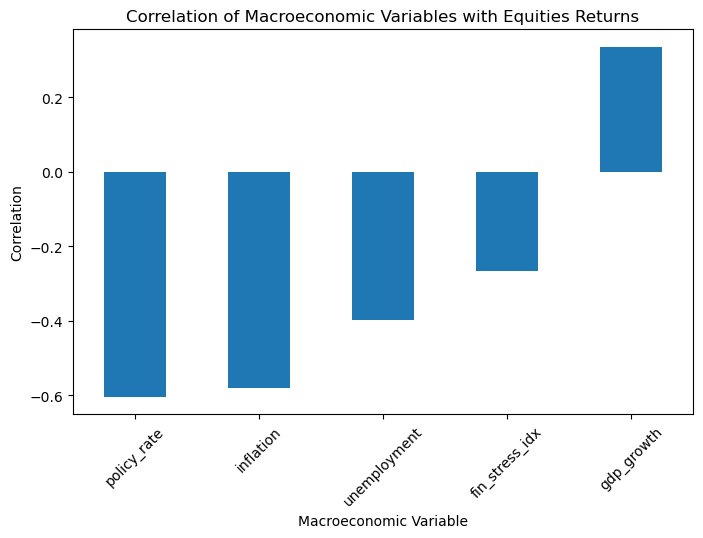

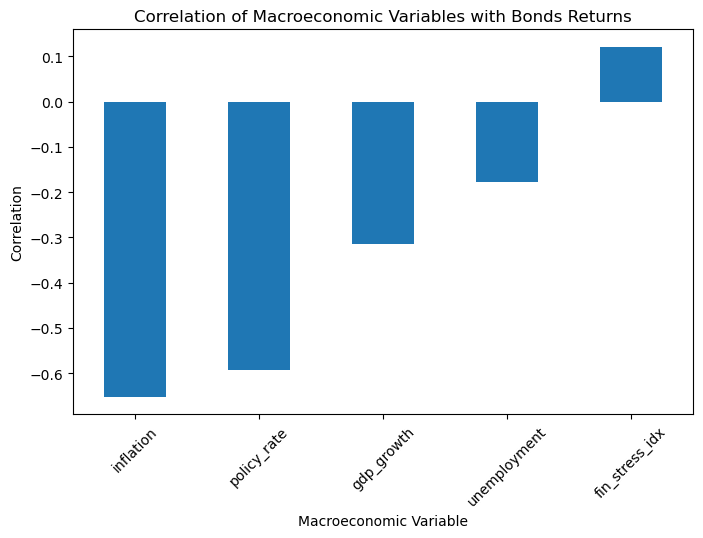

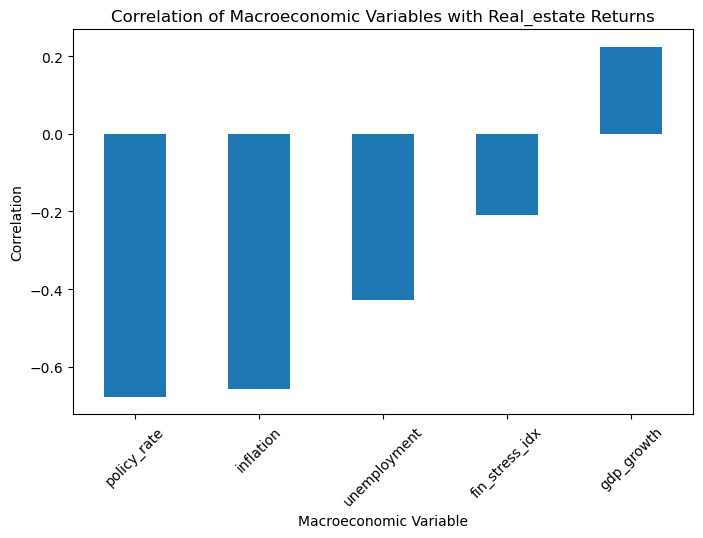

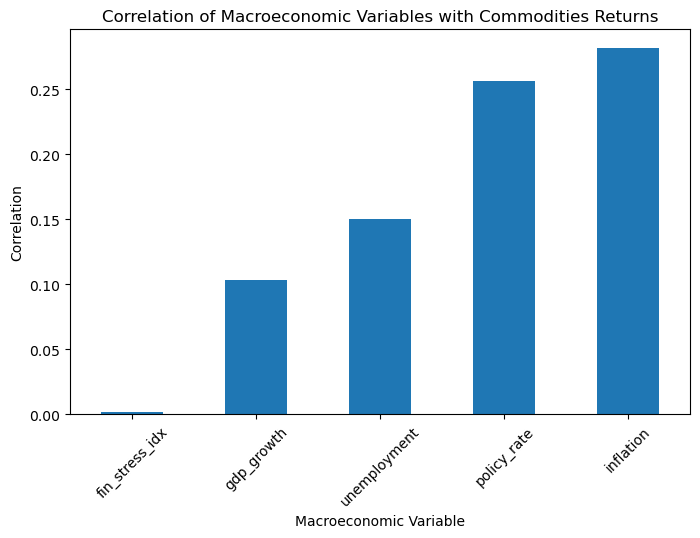

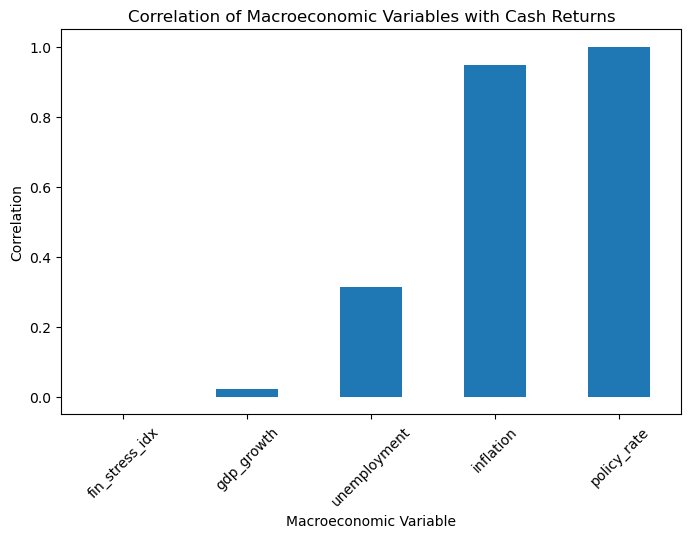

In [31]:
asset_cols = ["equities", "bonds", "real_estate", "commodities", "cash"]
macro_cols = ["gdp_growth", "inflation", "policy_rate", "unemployment", "fin_stress_idx"]

for asset in asset_cols:
    corr_series = merged_df[macro_cols + [asset]].corr(numeric_only=True)[asset].drop(asset).sort_values()

    plt.figure(figsize=(8, 5))
    corr_series.plot(kind="bar")
    plt.title(f"Correlation of Macroeconomic Variables with {asset.capitalize()} Returns")
    plt.xlabel("Macroeconomic Variable")
    plt.ylabel("Correlation")
    plt.xticks(rotation=45)
    plt.show()

### Interpretation

These charts isolate the relationship between each asset class and the selected macroeconomic variables.

This allows us to observe that:
- Different asset classes respond differently to economic conditions
- Risky assets such as equities and commodities may be more sensitive to growth and stress variables
- More defensive assets such as cash and bonds may exhibit different correlation patterns

### Key Insight

Asset classes do not react uniformly to macroeconomic conditions. This supports the idea that investment performance depends on both asset type and macro regime.

### Next Step

We now examine how equity returns vary across countries and over time in order to identify broader global patterns.

## 37. Equity Returns Across Countries and Time

In this step, we visualize equity returns by country and year using a heatmap.

The purpose is to:
- Identify periods of broad market weakness or strength
- Compare cross-country return patterns
- Visually connect macroeconomic conditions with asset performance over time

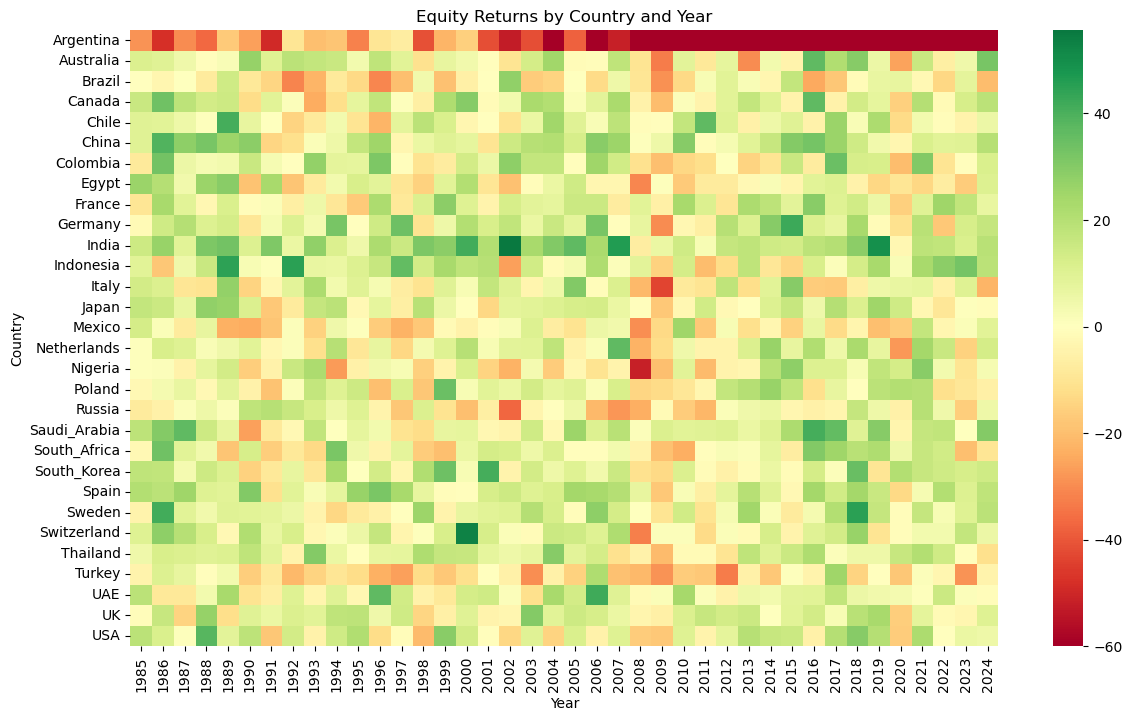

In [32]:
pivot_equities = merged_df.pivot_table(
    values="equities",
    index="country",
    columns="year"
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_equities, cmap="RdYlGn", center=0)
plt.title("Equity Returns by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

### Interpretation

The heatmap shows how equity returns vary both across countries and across years.

This allows us to identify:
- Years in which many countries experienced weaker equity performance
- Periods of broad global recovery or strength
- Countries with relatively more stable or more volatile return patterns

### Financial Insight

Financial markets tend to react in clusters during major macroeconomic shocks. Negative return patterns appearing across multiple countries at the same time may indicate common global stress factors.

### Next Step

We next examine how average asset class returns evolve over time.

## 38. Asset Class Performance Over Time

This analysis examines how average returns for each asset class evolve over time.

The purpose is to:
- Identify broad market cycles
- Compare long-term performance patterns across asset classes
- Observe whether different assets react differently across economic periods

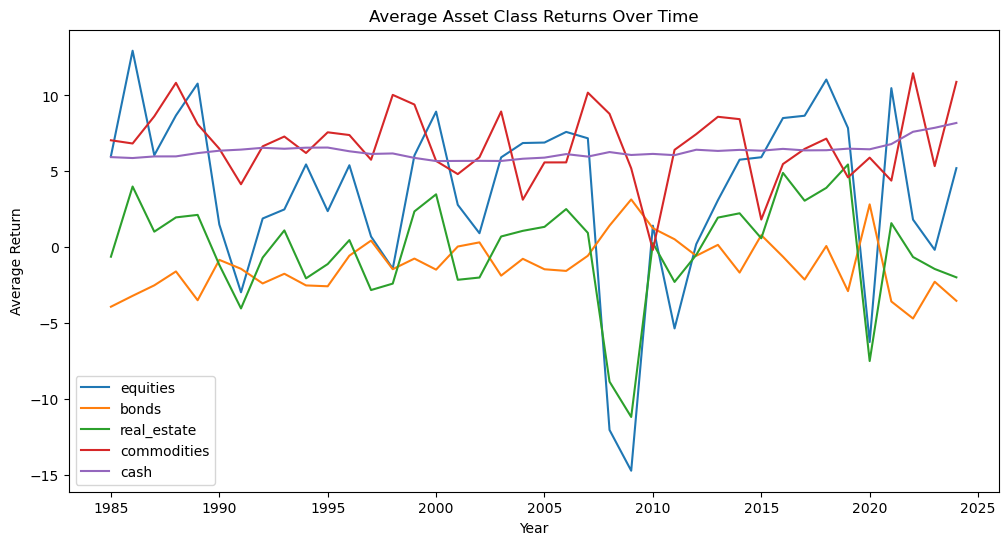

In [33]:
returns_by_year = merged_df.groupby("year")[asset_cols].mean()

plt.figure(figsize=(12, 6))
for col in asset_cols:
    plt.plot(returns_by_year.index, returns_by_year[col], label=col)

plt.title("Average Asset Class Returns Over Time")
plt.xlabel("Year")
plt.ylabel("Average Return")
plt.legend()
plt.show()

### Interpretation

The chart shows the average return path of each asset class over time.

It helps reveal:
- Which asset classes are more cyclical
- Which assets behave more defensively
- Whether returns tend to move together during major economic periods

### Financial Insight

Riskier asset classes may exhibit stronger expansion and contraction cycles, while more defensive assets may show lower volatility and more stable performance. We can further observe during the 2008 financial crisis, the equities and real estate experienced significant decrease. 

### Next Step

We now compare the distribution of equity returns between developed and emerging markets.

## 39. Equity Returns by Development Level

In this section, we compare the distribution of equity returns between developed and emerging markets.

The objective is to:
- Compare average return levels
- Compare volatility and dispersion
- Identify whether emerging markets show a wider spread of outcomes

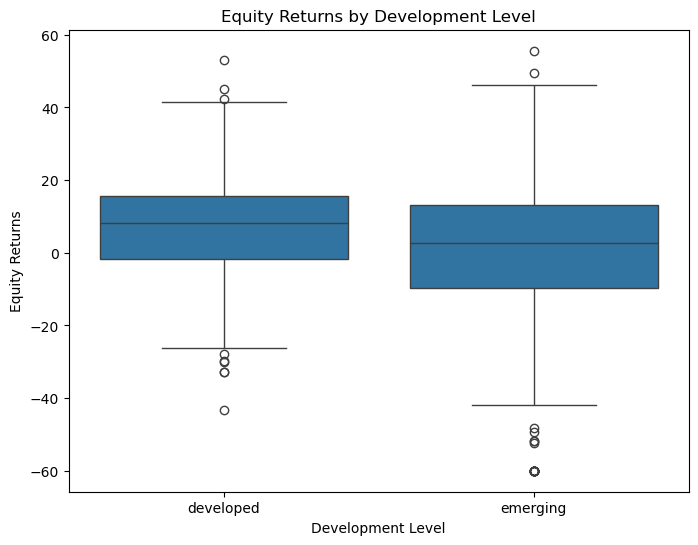

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=merged_df, x="dev_level", y="equities")
plt.title("Equity Returns by Development Level")
plt.xlabel("Development Level")
plt.ylabel("Equity Returns")
plt.show()

### Interpretation

The boxplot reveals differences in the distribution of equity returns across development groups.

This helps us compare:
- Median returns
- Dispersion of returns
- Frequency of extreme values

### Financial Insight

Emerging markets are often associated with higher volatility and wider return distributions, which reflects the higher risk-return tradeoff typically observed in international finance.

### Next Step

We now build a richer visual relationship between growth, equity returns, and financial stress.

## 40. Joint Relationship Between Growth, Returns, and Financial Stress

This visualization combines three variables in a single chart:

- GDP growth on the x-axis
- Equity returns on the y-axis
- Financial stress represented by bubble size

The objective is to explore whether financial stress modifies the relationship between economic growth and equity returns.

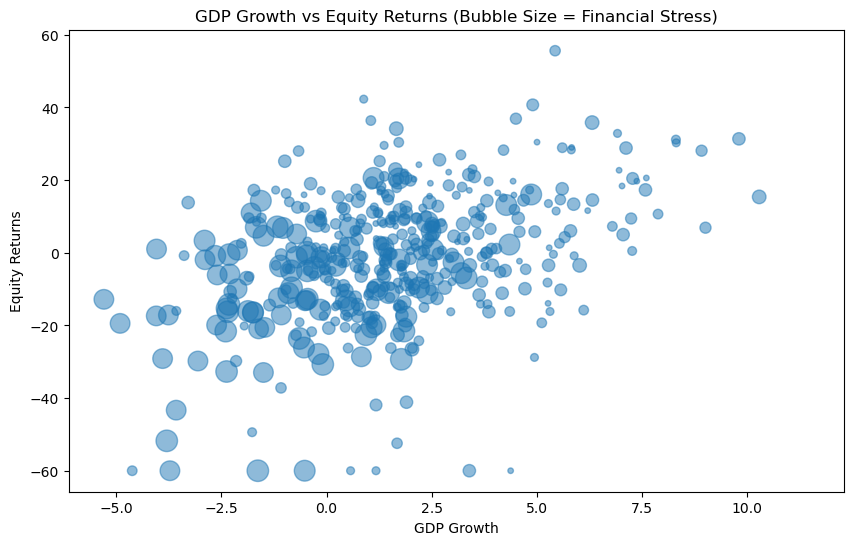

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(
    merged_df["gdp_growth"],
    merged_df["equities"],
    s=merged_df["fin_stress_idx"] * 80,
    alpha=0.5
)

plt.title("GDP Growth vs Equity Returns (Bubble Size = Financial Stress)")
plt.xlabel("GDP Growth")
plt.ylabel("Equity Returns")
plt.show()

### Interpretation

This chart allows us to simultaneously inspect economic growth, equity returns, and financial stress.

It suggests that:
- Stronger growth is often associated with stronger equity performance
- Higher financial stress may weaken this relationship
- Macro-financial interactions are more complex than a simple one-variable relationship

### Key Insight

This visualization supports the decision to use both linear and non-linear models, since the relationship between macro variables and returns is likely influenced by multiple interacting effects.

### Next Step

The next part of the project will strengthen the theoretical and mathematical explanation behind the modeling methods used.

## 41. Code Refactoring and Reproducibility

At this stage, the project transitions from exploratory development to a more structured and maintainable workflow.

The objective of this step is to:
- Reduce code duplication
- Improve readability
- Separate reusable logic from the main analysis
- Ensure that the project can be easily reproduced and extended

Refactoring is an important part of real-world data science projects, where code clarity and maintainability are critical.

## 42. Helper Functions

To improve code organization, we define reusable helper functions for common operations such as:

- Plotting correlations
- Generating summary tables
- Visualizing relationships

This avoids repetition and makes the notebook easier to maintain.

In [36]:
def plot_target_correlation(df, target, features):
    corr_series = df[features + [target]].corr(numeric_only=True)[target].drop(target).sort_values()
    
    plt.figure(figsize=(8, 5))
    corr_series.plot(kind="bar")
    plt.title(f"Correlation with {target}")
    plt.xlabel("Features")
    plt.ylabel("Correlation")
    plt.xticks(rotation=45)
    plt.show()


def plot_time_series(df, group_col, value_cols, title):
    grouped = df.groupby(group_col)[value_cols].mean()
    
    plt.figure(figsize=(12, 6))
    for col in value_cols:
        plt.plot(grouped.index, grouped[col], label=col)
    
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel("Value")
    plt.legend()
    plt.show()


def plot_scatter(df, x, y, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(title)
    plt.show()

### Interpretation

Reusable functions have been introduced to standardize common operations.

This improves:
- Readability
- Consistency across visualizations
- Ease of extending the analysis

### Next Step

We will apply these functions to replace repeated plotting logic in the notebook.

## 43. Applying Refactored Functions

In this step, we replace previously written plotting code with reusable functions.

This ensures:
- Consistency across outputs
- Reduced duplication
- Easier updates if visualization logic changes

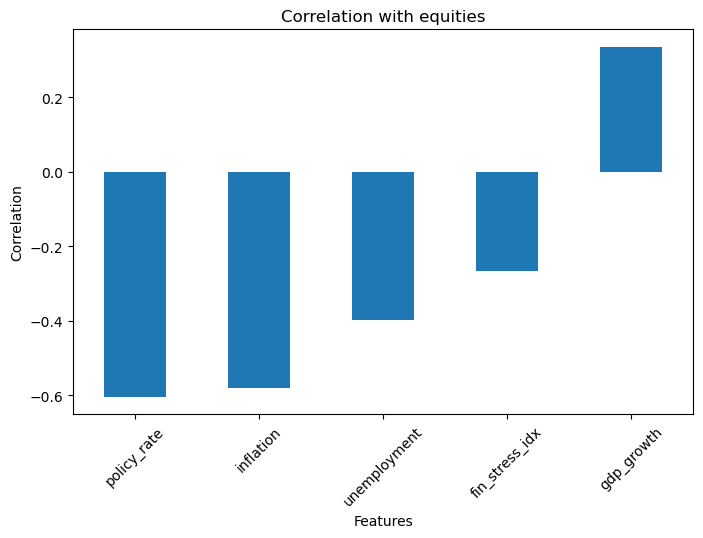

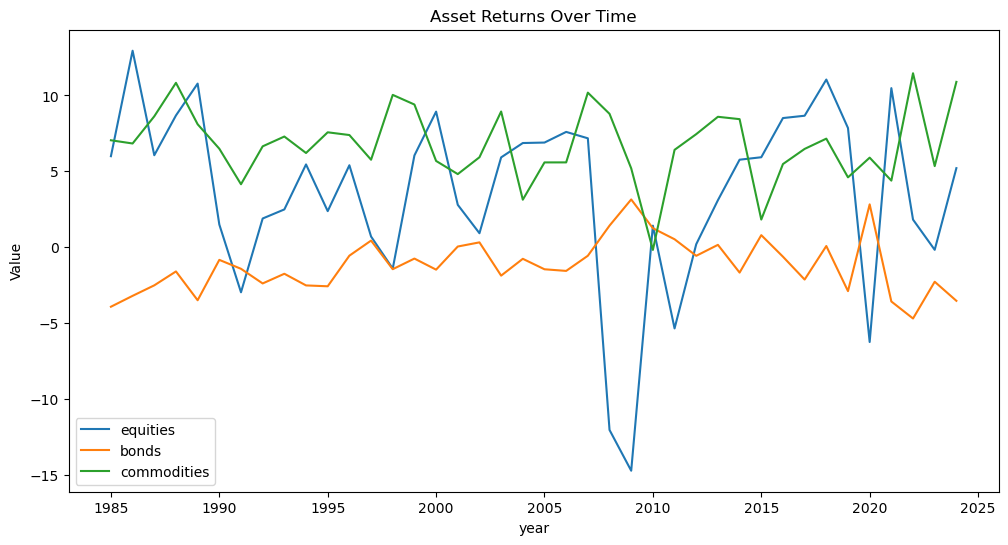

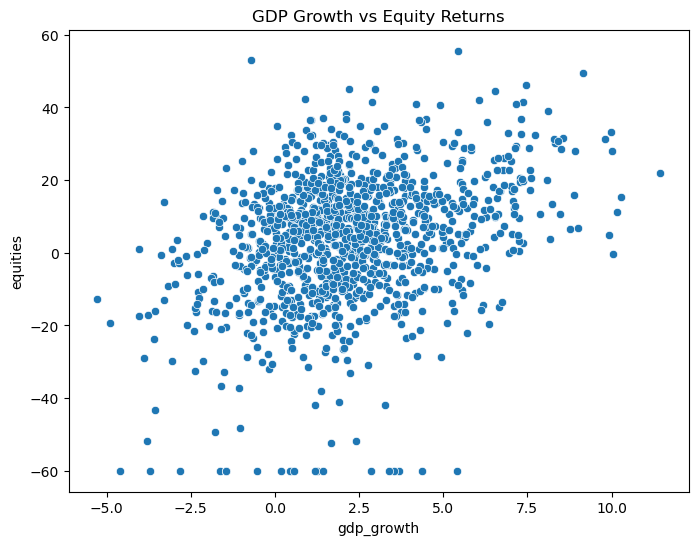

In [37]:
plot_target_correlation(
    merged_df,
    target="equities",
    features=["gdp_growth", "inflation", "policy_rate", "unemployment", "fin_stress_idx"]
)

plot_time_series(
    merged_df,
    group_col="year",
    value_cols=["equities", "bonds", "commodities"],
    title="Asset Returns Over Time"
)

plot_scatter(
    merged_df,
    x="gdp_growth",
    y="equities",
    title="GDP Growth vs Equity Returns"
)

### Interpretation

The use of reusable functions simplifies the notebook and improves consistency.

The same analytical results are obtained with:
- Less code
- Clearer structure
- Improved maintainability

### Key Insight

Refactoring is not about changing results, but about improving how the code is written and organized.

### Next Step

We will ensure that the project is fully reproducible and runs cleanly from start to finish.

## 44. Reproducibility

Reproducibility is a key requirement in data science projects.

To ensure that results can be replicated:
- The dataset is saved after processing
- The workflow follows a clear sequence of steps
- All code cells can be executed from top to bottom

This ensures that another user can run the notebook and obtain the same results.

In [38]:
test_df = pd.read_csv("merged_macro_asset.csv")

print("Re-loaded dataset shape:", test_df.shape)
test_df.head()

Re-loaded dataset shape: (1200, 21)


,country,region,dev_level,year,gdp_growth,gdp_level,inflation,policy_rate,unemployment,current_account,...,fx_change,biz_confidence,fin_stress_idx,shock_event_x,equities,bonds,real_estate,commodities,cash,shock_event_y
0,USA,NorthAmerica,developed,1985,2.683,102.68,1.668,4.127,4.129,-6.902,...,0.505,54.42,0.0,NaN,18.93,7.05,-7.43,2.10,3.65,NaN
1,USA,NorthAmerica,developed,1986,2.627,105.38,1.152,4.166,4.075,-2.868,...,1.339,52.68,0.0,NaN,11.52,10.24,0.03,-27.53,3.78,NaN
2,USA,NorthAmerica,developed,1987,2.317,107.82,0.794,4.095,3.817,-3.370,...,2.957,52.57,0.8,Black Monday,0.58,-4.12,3.02,21.01,3.10,Black Monday
3,USA,NorthAmerica,developed,1988,2.105,110.09,0.854,3.893,4.130,-2.175,...,4.777,52.99,0.0,NaN,38.04,0.10,7.07,-15.35,3.32,NaN
4,USA,NorthAmerica,developed,1989,1.897,112.18,0.532,3.668,4.616,-3.228,...,-1.059,55.75,0.0,NaN,8.31,-2.60,29.12,-4.71,2.97,NaN


### Interpretation

The processed dataset can be successfully reloaded.

This confirms that:
- The data pipeline is complete
- Intermediate results are preserved
- The workflow does not rely on hidden steps

### Key Insight

Saving processed data improves efficiency and reproducibility, especially in larger projects.

### Next Step

We now finalize the structure and prepare the project for interpretation and reporting.

## 45. Notebook Cleanup

At this stage, we ensure that the notebook is clean and easy to follow.

This includes:
- Removing redundant code
- Ensuring consistent formatting
- Keeping only relevant outputs
- Structuring sections logically

### Interpretation

The notebook is now structured in a clear and logical way.

This improves:
- Readability
- User experience
- Overall presentation quality

### Next Step

We will move to the final stage of the project, where we summarize findings, discuss limitations, and present conclusions.

## 46. Key Findings

In this section, the results of the exploratory and modeling analysis are summarized in a concise and structured way.

The goal is to:
- Connect the visual and statistical results
- Highlight the most important macro-financial relationships
- Clearly answer what the analysis has shown so far

### Main Findings

The analysis produced several important findings.

#### 1. Macroeconomic conditions are linked to asset returns
The exploratory analysis showed that asset returns are related to macroeconomic variables such as GDP growth, inflation, policy rate, unemployment, and financial stress.

#### 2. Risky asset classes are more sensitive to macro conditions
Equities and commodities showed wider distributions and stronger variation across time, indicating greater exposure to economic cycles and financial stress.

#### 3. Financial stress is an important negative driver
Periods associated with higher financial stress tended to coincide with weaker equity performance. This was visible both in the visual analysis and in the modeling results.

#### 4. Development level matters
Developed and emerging markets showed different return distributions, suggesting that macroeconomic transmission and market behavior differ across economic groups.

#### 5. Relationships are not purely linear
The Random Forest model improved performance relative to the baseline linear regression model, suggesting that the relationship between macroeconomic variables and asset returns contains non-linear effects and interactions.

### Interpretation

The findings suggest that macroeconomic indicators do not merely describe the economic environment, but also help explain differences in financial market performance.

### Next Step

The next step is to acknowledge the limitations of the analysis in order to keep the conclusions realistic and academically sound.

## 47. Limitations

No empirical analysis is without limitations. In this section, the main constraints of the project are discussed in order to keep the interpretation balanced and realistic.

### Main Limitations

This project has several important limitations.

#### 1. Synthetic dataset
The macroeconomic dataset used in the project is synthetic, although it is calibrated to realistic macroeconomic relationships. This means that the project is suitable for methodology and modeling practice, but the results should not be interpreted as direct evidence about real-world countries. 

#### 2. Limited set of predictors
Asset returns are influenced by many factors beyond the selected macroeconomic variables, including market sentiment, valuation levels, political events, expectations, and global shocks.

#### 3. Static annual structure
The main merged dataset is annual, which simplifies the analysis but does not capture shorter-term market dynamics and time-series behavior.

#### 4. No lag structure
The current models use contemporaneous variables. In practice, macroeconomic variables may affect markets with time lags rather than immediately.

#### 5. Limited model scope
Only two predictive approaches were used: Linear Regression and Random Forest. Other approaches, including panel methods, regularized regression, or time-series models, may provide additional insight.

### Interpretation

These limitations do not invalidate the project. Instead, they define the scope of the conclusions.

### Key Insight

The project should be understood as a structured methodological analysis of macro-financial relationships, not as a final real-world investment model.

### Next Step

Having defined the scope and limitations, we can now present the overall conclusion of the project.

## 48. Conclusion

This section provides the final answer to the research question and summarizes the practical significance of the project.

### Final Conclusion

This project investigated how macroeconomic conditions influence asset class returns across countries and over time.

By combining macroeconomic indicators with asset return data, the analysis showed that macro variables such as GDP growth, inflation, policy rate, unemployment, and financial stress help explain differences in market performance.

The results suggest that:

- Asset returns are linked to the macroeconomic environment
- Risky assets are more exposed to macro-financial conditions
- Financial stress plays an especially important role in weakening equity performance
- Non-linear modeling adds value beyond a simple linear framework

### Answer to the Research Question

Macroeconomic conditions significantly influence asset returns, but the relationship is complex and not purely linear.

### Practical Implications

The results imply that:
- Investors can use macroeconomic indicators as part of asset allocation analysis
- Risk management frameworks should account for changes in financial stress
- Market interpretation benefits from combining economic and financial data rather than analyzing returns in isolation

### Final Insight

Macroeconomic variables do not fully determine market returns, but they provide a valuable framework for understanding broad financial behavior across countries and periods.

### Interpretation

The project has now moved from raw data to a complete analytical narrative:
- Problem definition
- Data integration
- Exploratory analysis
- Modeling
- Interpretation
- Conclusion

### Next Step

The final technical step is to document all sources and polish the project for submission.

## 49. References

This section documents the sources used for the project, including datasets, libraries, and referenced data providers.

### Datasets
- Kaggle: Macro Indicators Dataset
- Kaggle: Asset Returns Dataset

### Dataset Documentation and Referenced Providers
- IMF World Economic Outlook
- World Bank Open Data
- Federal Reserve Economic Data (FRED)
- OECD Statistics
- BIS Statistics
- U.S. Energy Information Administration (EIA)

### Python Libraries
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-learn

### Notes
The macro dataset is synthetic and calibrated using real-world reference sources, as described in the dataset documentation.